# Notebook 06 — Détection d'impact : nouvelle carte & ban

Quantifie l'impact d'une **nouvelle carte** (bridge score, Δmeta_score) ou d'un **ban** (détection de chute, Δmeta_score) sur la méta.

**Tables créées :** `card_impact`, `ban_impact`  
**DB :** `data/yugioh.db`

In [ ]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DB = 'data/yugioh.db'
conn = sqlite3.connect(DB)

ms = pd.read_sql_query(
    "SELECT month, archetype, meta_score FROM meta_scores",
    conn, parse_dates=['month']
)
ms['month'] = ms['month'].dt.to_period('M')
print(f"meta_scores: {len(ms)} lignes, {ms['archetype'].nunique()} archetypes, {ms['month'].nunique()} mois")
print(f"Période : {ms['month'].min()} → {ms['month'].max()}")

meta_scores: 462 lignes, 122 archetypes, 30 mois
Période : 2024-01 → 2026-06


## Fonctions utilitaires

In [ ]:
def card_monthly_usage(card_name):
    """Usage mensuel d'une carte par archetype (TCG uniquement)."""
    q = """
        SELECT strftime('%Y-%m', td.created) as month,
               td.archetype, COUNT(*) as deck_count
        FROM deck_cards dc
        JOIN tournament_decks td ON td.id = dc.deck_id
        WHERE dc.card_name = ? AND td.ocg = 0
        GROUP BY month, td.archetype
        ORDER BY month, deck_count DESC
    """
    df = pd.read_sql_query(q, conn, params=(card_name,))
    df['month'] = pd.to_datetime(df['month']).dt.to_period('M')
    return df


def card_total_monthly(card_name):
    return card_monthly_usage(card_name).groupby('month')['deck_count'].sum().sort_index()


def delta_meta_score(archetypes, date_event, window_months=3):
    """Δmeta_score = moyenne post (window_months) − moyenne pré."""
    rows = []
    for arch in archetypes:
        pre  = ms[(ms['archetype'] == arch) & (ms['month'] < date_event)
                  & (ms['month'] >= date_event - window_months)]
        post = ms[(ms['archetype'] == arch) & (ms['month'] >= date_event)
                  & (ms['month'] < date_event + window_months)]
        pre_s  = pre['meta_score'].mean()  if len(pre)  else float('nan')
        post_s = post['meta_score'].mean() if len(post) else float('nan')
        delta  = post_s - pre_s if (pre_s == pre_s and post_s == post_s) else float('nan')
        rows.append({'archetype': arch, 'pre_score': pre_s, 'post_score': post_s, 'delta': delta})
    df = pd.DataFrame(rows)
    return df[df['delta'].notna()].sort_values('delta', ascending=False) if not df.empty else df


def infer_ban_date(card_name, min_peak_decks=10):
    """Détecte le mois de ban par plus grande chute MoM post-pic."""
    usage = card_total_monthly(card_name)
    if len(usage) < 3: return None
    post_peak = usage[usage.index >= usage.idxmax()]
    if post_peak.max() < min_peak_decks: return None
    mom = post_peak.pct_change()
    worst = mom.idxmin()
    return worst if mom[worst] < -0.4 else None


print('Fonctions chargées.')

Fonctions chargées.


## Partie A — Impact d'une nouvelle carte : Bonfire

**Bonfire** (Spell, release TCG 2024-01-18) : "Add 1 Level 4 or lower Pyro monster from your Deck to your hand."

Carte *bridge* par excellence : elle s'insère instantanément dans tous les archetypes Pyro.
**Métriques :** bridge score = n_archetypes × log(total_decks_3m) · Δmeta_score des archetypes adoptants.

In [ ]:
CARD_NEW     = 'Bonfire'
release_month = pd.Period('2024-01', freq='M')

bf_total = card_total_monthly(CARD_NEW)
bf_usage = card_monthly_usage(CARD_NEW)

# Archetypes adoptants dans les 3 mois post-release
post90 = bf_usage[bf_usage['month'].isin(
    [release_month, release_month+1, release_month+2]
)]
bridge_archs = post90.groupby('archetype')['deck_count'].sum().sort_values(ascending=False)

n_a, tot = len(bridge_archs), bridge_archs.sum()
bridge_score = n_a * np.log1p(tot)

print(f'Archetypes adoptant {CARD_NEW} dans les 3 mois post-release :')
print(bridge_archs.to_string())
print()
print(f'Bridge Score = {n_a} archetypes × log({tot} decks) = {bridge_score:.2f}')
print()
print('Δmeta_score des archetypes adoptants :')
delta_bf = delta_meta_score(bridge_archs.index.tolist(), release_month)
if len(delta_bf):
    print(delta_bf.to_string(index=False))
else:
    print('(pas assez de data pré-release — méta démarre en 2024-01)')


Archetypes adoptant Bonfire dans les 3 mois post-release :
Snake-Eye Fire King    173
Snake-Eye              159
Rescue-ACE               7
Volcanic                 3
Centur-Ion               1
Mikanko                  1
dtype: int64

Bridge Score = 6 archetypes × log(344 decks) = 35.06

Δmeta_score des archetypes adoptants :
(pas assez de data pré-release — méta démarre en 2024-01)


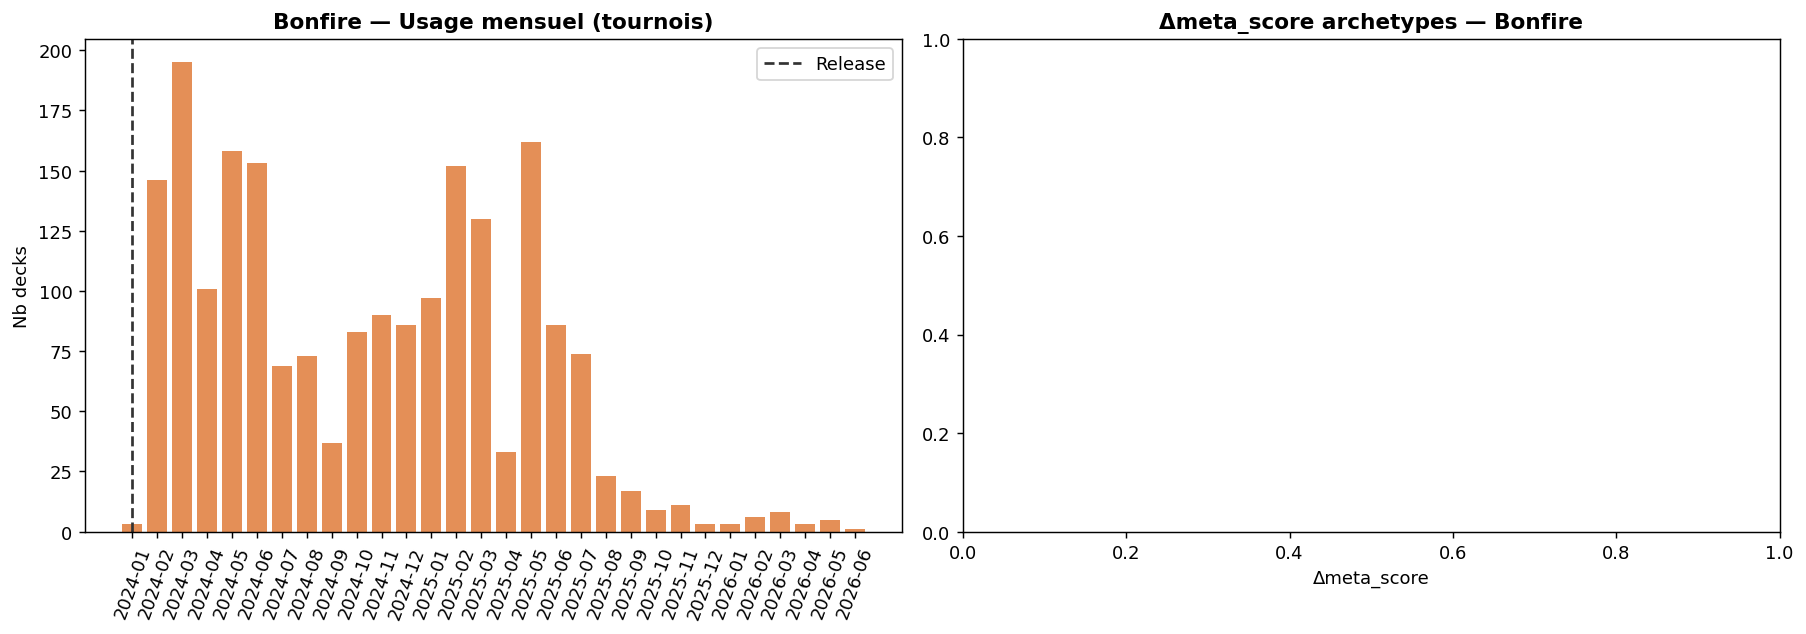

In [ ]:
# Visualisation : usage mensuel Bonfire + archetypes principaux
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
x = [str(p) for p in bf_total.index]
ax1.bar(x, bf_total.values, color='#e07b39', alpha=0.85)
ax1.axvline('2024-01', color='#333', ls='--', lw=1.5, label='Release')
ax1.set_title('Bonfire — Usage mensuel (tournois TCG)', fontweight='bold')
ax1.set_ylabel('Nb decks'); ax1.tick_params(axis='x', rotation=70); ax1.legend()

# Top archetypes utilisant Bonfire (total)
ax2 = axes[1]
top_archs = bf_usage.groupby('archetype')['deck_count'].sum().sort_values().tail(10)
ax2.barh(top_archs.index, top_archs.values, color='#e07b39', alpha=0.75)
ax2.set_title('Bonfire — Top archetypes utilisateurs', fontweight='bold')
ax2.set_xlabel('Total decks')

plt.tight_layout()
plt.savefig('data/impact_bonfire.png', dpi=130, bbox_inches='tight')
plt.show()

## Partie B — Impact d'un ban : Moon of the Closed Heaven

**Moon of the Closed Heaven** (Link-2, release 2024-07-18, statut actuel : **Forbidden**)  
Carte pont pour les combos Link-5 dans Snake-Eye Fiendsmith, Yubel, puis Ryzeal/Mitsurugi.

**Méthode :** détecter la date de ban via la plus grande chute MoM d'usage (>40%), puis mesurer Δmeta_score.

In [ ]:
CARD_BAN = 'Moon of the Closed Heaven'

moon_total = card_total_monthly(CARD_BAN)
moon_usage = card_monthly_usage(CARD_BAN)

ban_month = infer_ban_date(CARD_BAN)
print(f'Ban inféré automatiquement : {ban_month}')
print()
print('Changements mois-sur-mois :')
for p, v in moon_total.pct_change().dropna().items():
    marker = '  ← ban inféré' if p == ban_month else ''
    print(f'  {p}  {v:+.1%}{marker}')

Ban inféré automatiquement : 2025-09

Changements mois-sur-mois :
  2024-08  +23.0%
  2024-09  +6.0%
  2024-10  -29.0%
  2024-11  +4.0%
  2024-12  +30.0%
  2025-01  -13.0%
  2025-02  +13.0%
  2025-03  -7.0%
  2025-04  -39.0%
  2025-05  +35.0%
  2025-06  -28.0%
  2025-07  -51.0%
  2025-08  -23.0%
  2025-09  -61.0%  ← ban inféré


In [ ]:
# Archetypes affectés 3 mois avant le ban
pre3_m = moon_usage[
    (moon_usage['month'] < ban_month) &
    (moon_usage['month'] >= ban_month - 3)
]
moon_archs = pre3_m.groupby('archetype')['deck_count'].sum().sort_values(ascending=False)
print(f'Archetypes utilisant Moon (3 mois avant {ban_month}) :')
print(moon_archs.to_string())

print()
delta_ban = delta_meta_score(moon_archs.index.tolist(), ban_month)
print('Δmeta_score post-ban :')
print(delta_ban.to_string(index=False))

Archetypes utilisant Moon (3 mois avant 2025-09) :
Ryzeal Mitsurugi    31
Memento             27
Mitsurugi           14
Yubel                4
Dracotail            4
dtype: int64

Δmeta_score post-ban :
          archetype  pre_score  post_score     delta
White Forest Azamina   0.0791     0.1950   +0.1160
       Tenpai Dragon   0.0626     0.1169   +0.0543
            Memento    0.1332     0.0655   -0.0678
           Lunalight   0.2460     0.1812   -0.0648


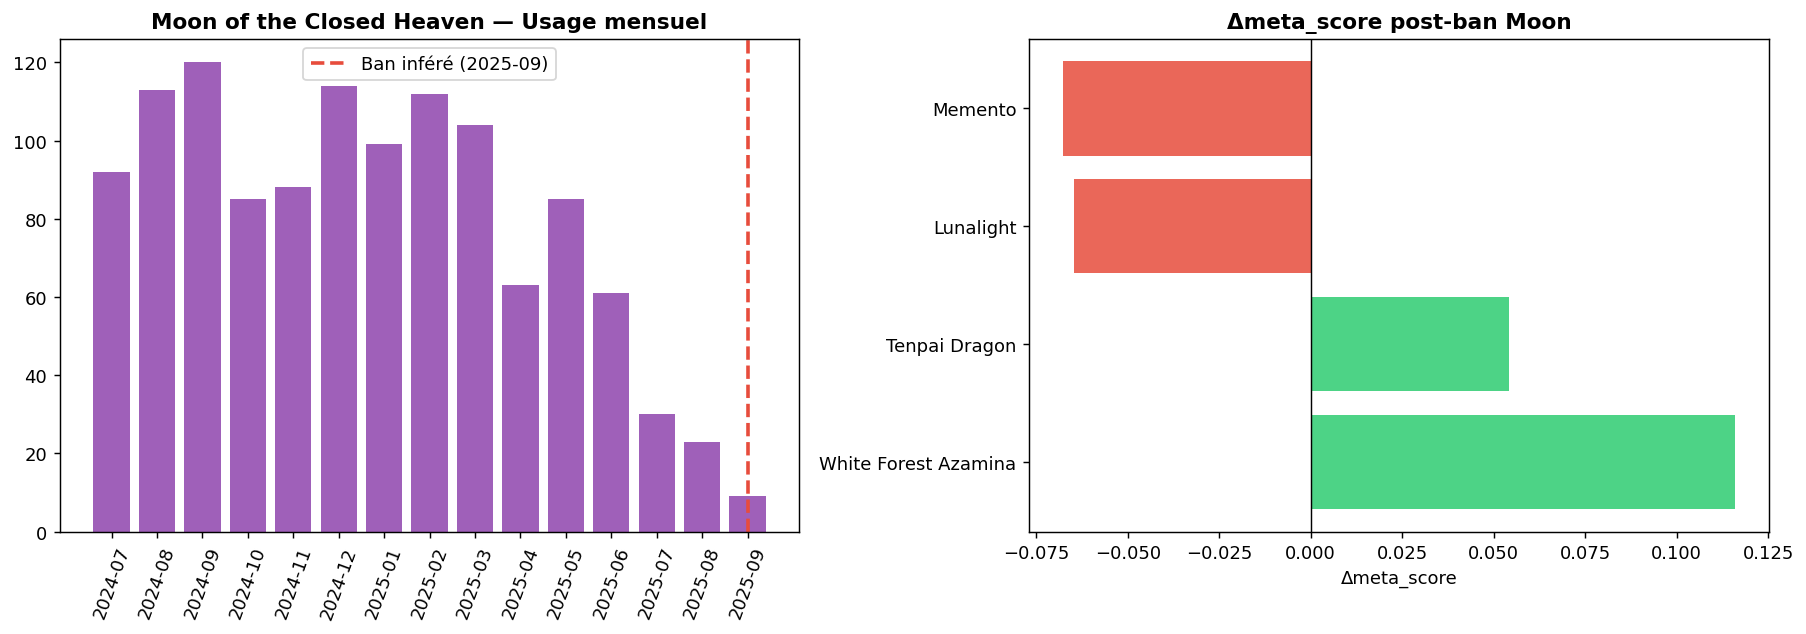

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
xm = [str(p) for p in moon_total.index]
ax1.bar(xm, moon_total.values, color='#8e44ad', alpha=0.85)
ax1.axvline(str(ban_month), color='#e74c3c', ls='--', lw=2, label=f'Ban inféré ({ban_month})')
ax1.set_title('Moon of the Closed Heaven — Usage mensuel', fontweight='bold')
ax1.set_ylabel('Nb decks'); ax1.tick_params(axis='x', rotation=70); ax1.legend()

ax2 = axes[1]
c4 = ['#2ecc71' if v > 0 else '#e74c3c' for v in delta_ban['delta']]
ax2.barh(delta_ban['archetype'], delta_ban['delta'], color=c4, alpha=0.85)
ax2.axvline(0, color='black', lw=0.8)
ax2.set_xlabel('Δmeta_score'); ax2.set_title('Δmeta_score post-ban Moon', fontweight='bold')

plt.tight_layout()
plt.savefig('data/impact_ban_moon.png', dpi=130, bbox_inches='tight')
plt.show()

## Partie C — Scan général : toutes les cartes bannées/limitées

Pour chaque carte Forbidden/Limited avec ≥50 apparitions en tournoi TCG depuis 2022,
on détecte automatiquement la date de ban et calcule le Δmeta_score.

In [ ]:
q = """
    SELECT c.name, c.ban_tcg, c.tcg_date, COUNT(dc.id) as total_appearances
    FROM cards c
    JOIN deck_cards dc ON dc.card_name = c.name
    WHERE c.ban_tcg IN ('Forbidden', 'Limited')
      AND c.tcg_date >= '2022-01-01'
    GROUP BY c.name
    HAVING total_appearances >= 50
    ORDER BY total_appearances DESC
"""
restricted = pd.read_sql_query(q, conn)
print(f'{len(restricted)} cartes bannées/limitées éligibles')

scan_rows = []
for _, row in restricted.iterrows():
    total = card_total_monthly(row['name'])
    if len(total) < 3: continue
    db = infer_ban_date(row['name'])
    if db is None: continue
    usage = card_monthly_usage(row['name'])
    pre = usage[(usage['month'] < db) & (usage['month'] >= db - 3)]
    archs = pre.groupby('archetype')['deck_count'].sum()
    top_a = archs.idxmax() if len(archs) else 'Unknown'
    d = delta_meta_score([top_a], db)
    dv = float(d.iloc[0]['delta']) if len(d) else float('nan')
    scan_rows.append({'card': row['name'], 'ban_status': row['ban_tcg'],
        'ban_month_inferred': str(db), 'peak_usage': int(total.max()),
        'drop_ratio': round(float(total.pct_change().min()), 3),
        'top_archetype': top_a,
        'delta_meta_score': round(dv, 4) if dv == dv else None,
        'n_archetypes_affected': len(archs),
        'total_appearances': int(row['total_appearances'])})

scan_df = pd.DataFrame(scan_rows).sort_values('peak_usage', ascending=False)
print(f'\n{len(scan_df)} bans détectés automatiquement\n')
print(scan_df[['card','ban_status','ban_month_inferred','peak_usage','top_archetype','delta_meta_score']].to_string(index=False))

33 cartes bannées/limitées éligibles

28 bans détectés automatiquement

                              card ban_status ban_month_inferred  peak_usage       top_archetype  delta_meta_score
                 Bystial Magnamhut    Limited            2026-06         281             Branded            0.0596
                  Ryzeal Detonator    Limited            2026-06         221              Ryzeal           -0.0056
Original Sinful Spoils - Snake-Eye    Limited            2024-12         207 Snake-Eye Fire King              None
                           Bonfire    Limited            2026-06         195    Ryzeal Mitsurugi            0.0429
      Ame no Habakiri no Mitsurugi    Limited            2026-06         179           Mitsurugi           -0.0598
                      K9-66a Jokul    Limited            2026-06         121    Vanquish Soul K9           -0.0633
         Moon of the Closed Heaven  Forbidden            2025-09         120    Ryzeal Mitsurugi              None
        

## Partie D — Table card_impact : nouvelles cartes bridge

In [ ]:
q2 = """
    SELECT c.name, c.ban_tcg, c.tcg_date, COUNT(dc.id) as total_appearances
    FROM cards c
    JOIN deck_cards dc ON dc.card_name = c.name
    WHERE c.tcg_date >= '2023-06-01'
    GROUP BY c.name
    HAVING total_appearances >= 100
    ORDER BY total_appearances DESC
    LIMIT 35
"""
new_cards = pd.read_sql_query(q2, conn)

imp_rows = []
for _, row in new_cards.iterrows():
    card  = row['name']
    rel_m = pd.Period(pd.to_datetime(row['tcg_date']), freq='M')
    usage = card_monthly_usage(card)
    p90   = usage[(usage['month'] >= rel_m) & (usage['month'] < rel_m + 3)]
    n_a   = p90['archetype'].nunique()
    tot   = p90['deck_count'].sum()
    bs    = round(n_a * np.log1p(tot), 3) if tot > 0 else 0
    top_a = p90.groupby('archetype')['deck_count'].sum().idxmax() if tot > 0 else None
    d     = delta_meta_score([top_a], rel_m) if top_a else pd.DataFrame()
    dv    = float(d.iloc[0]['delta']) if len(d) else None
    imp_rows.append({'card_name': card, 'release_month': str(rel_m),
        'n_archetypes_3m': n_a, 'total_decks_3m': int(tot),
        'bridge_score': bs, 'top_archetype': top_a,
        'delta_meta_score_top_arch': round(dv, 4) if dv is not None else None})

card_impact_df = pd.DataFrame(imp_rows).sort_values('bridge_score', ascending=False)

print('Top cartes bridge :')
print(card_impact_df[['card_name','release_month','n_archetypes_3m','bridge_score',
                        'top_archetype','delta_meta_score_top_arch']].head(12).to_string(index=False))

# Écriture en DB
card_impact_df.to_sql('card_impact', conn, if_exists='replace', index=False)
scan_df.to_sql('ban_impact', conn, if_exists='replace', index=False)
conn.commit()
print(f'\n✓ card_impact ({len(card_impact_df)} lignes) + ban_impact ({len(scan_df)} lignes) sauvegardées en DB')

Top cartes bridge :
                card_name release_month  n_archetypes_3m  bridge_score        top_archetype  delta_meta_score_top_arch
         Mulcharmy Purulia       2024-07               30       177.728 Snake-Eye Fiendsmith                       None
 Moon of the Closed Heaven       2024-07               23       133.099 Snake-Eye Fiendsmith                       None
          Dominus Impulse        2024-10               23       129.600        Tenpai Dragon                       None
     Fiendsmith's Requiem        2024-07               21       121.460 Snake-Eye Fiendsmith                       None
      Fiendsmith Engraver        2024-07               21       121.396 Snake-Eye Fiendsmith                       None
      Fiendsmith's Tract         2024-07               20       115.115 Snake-Eye Fiendsmith                       None
    Fiendsmith's Sequence        2024-07               19       109.598 Snake-Eye Fiendsmith                       None
      Necroquip Princ


=== RÉSUMÉ FINAL ===
Cartes bridge analysées : 35
Top bridge card : Mulcharmy Purulia (score 177.7, 30 archetypes)
Bans détectés : 28
Tables en DB : card_impact, ban_impact


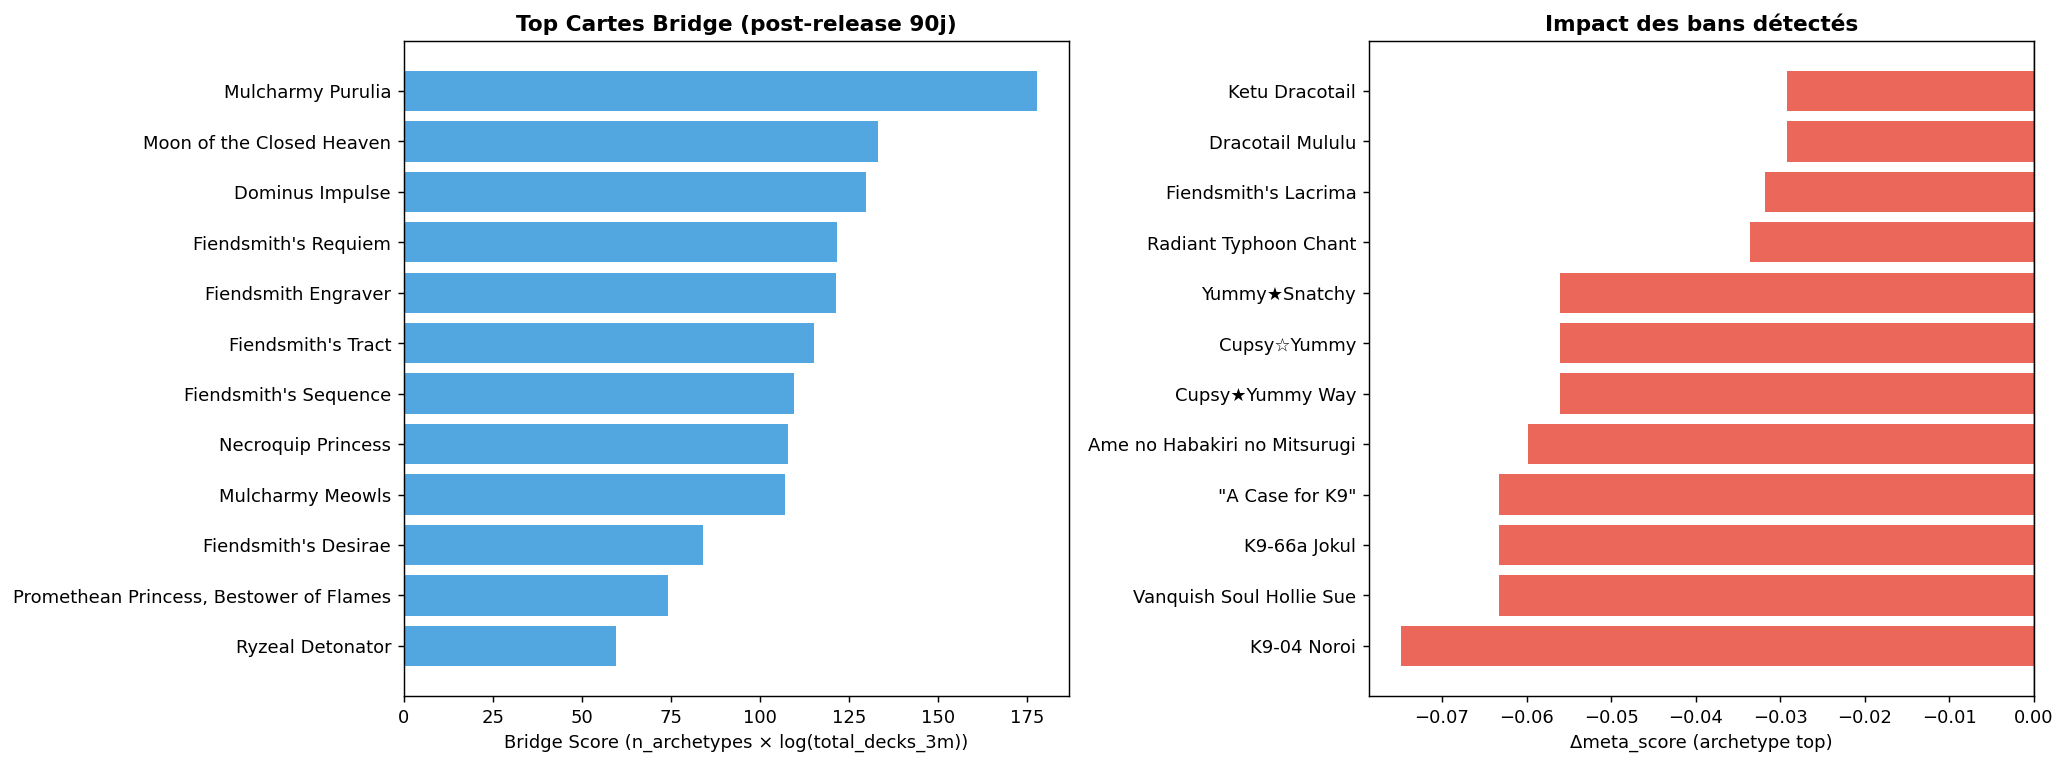

In [ ]:
# Visualisation finale
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top bridge cards
top12 = card_impact_df[card_impact_df['bridge_score'] > 0].head(12)
axes[0].barh(top12['card_name'], top12['bridge_score'], color='#3498db', alpha=0.85)
axes[0].set_xlabel('Bridge Score (n_archetypes × log(total_decks_3m))')
axes[0].set_title('Top Cartes Bridge (post-release 90j)', fontweight='bold')
axes[0].invert_yaxis()

# Ban impact
ban_plot = scan_df.dropna(subset=['delta_meta_score']).sort_values('delta_meta_score').head(12)
c2 = ['#e74c3c' if v < 0 else '#2ecc71' for v in ban_plot['delta_meta_score']]
axes[1].barh(ban_plot['card'], ban_plot['delta_meta_score'], color=c2, alpha=0.85)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_xlabel('Δmeta_score (archetype top)')
axes[1].set_title('Impact des bans détectés \n(Δmeta_score archetype principal)', fontweight='bold')

plt.tight_layout()
plt.savefig('data/impact_summary.png', dpi=130, bbox_inches='tight')
plt.show()

print()
print('=== RÉSUMÉ FINAL ===')
print(f'Cartes bridge analysées : {len(card_impact_df)}')
print(f'Top bridge card : {card_impact_df.iloc[0]["card_name"]} (score {card_impact_df.iloc[0]["bridge_score"]:.1f}, {card_impact_df.iloc[0]["n_archetypes_3m"]} archetypes)')
print(f'Bans détectés : {len(scan_df)}')
print(f'Tables en DB : card_impact, ban_impact')